In [40]:
import duckdb
import polars as pl
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

con = duckdb.connect()

In [33]:
!ls ../data/processed/*

../data/processed/daily:
level_01_daily_total.parquet	  level_07_daily_state_dept.parquet
level_02_daily_state.parquet	  level_08_daily_store_cat.parquet
level_03_daily_cat.parquet	  level_09_daily_store_dept.parquet
level_04_daily_dept.parquet	  level_10_daily_item.parquet
level_05_daily_state_cat.parquet  level_11_daily_item_state.parquet
level_06_daily_store.parquet	  level_12_daily_item_store.parquet

../data/processed/weekly:
level_01_weekly_total.parquet	   level_07_weekly_state_dept.parquet
level_02_weekly_state.parquet	   level_08_weekly_store_cat.parquet
level_03_weekly_cat.parquet	   level_09_weekly_store_dept.parquet
level_04_weekly_dept.parquet	   level_10_weekly_item.parquet
level_05_weekly_state_cat.parquet  level_11_weekly_item_state.parquet
level_06_weekly_store.parquet	   level_12_weekly_item_store.parquet


In [ ]:
DIR = "../data/processed/"
FILE = "daily/level_12_daily_item_store.parquet"
FILE_PATH = DIR + FILE

df = con.execute(f"SELECT * FROM '{FILE_PATH}' LIMIT 5").fetchdf()

df.head()


In [ ]:
query = f"""
SELECT series_id,
       COUNT(*) AS n_dias,
       COUNT(*) FILTER (WHERE sales > 0) AS n_dias_ventas,
       AVG(sales) FILTER (WHERE sales > 0) AS media_venta,
       STDDEV_SAMP(sales) FILTER (WHERE sales > 0) AS std_venta
FROM '{FILE_PATH}'
WHERE YEAR(date) = 2015
GROUP BY series_id
ORDER BY n_dias DESC
"""

df_demanda = con.execute(query).fetchdf()

df_demanda['adi'] = df_demanda['n_dias'] / df_demanda['n_dias_ventas']
df_demanda['cv'] = df_demanda['std_venta'] / df_demanda['media_venta']
df_demanda['cv2'] = df_demanda['cv'] ** 2

condiciones = [
    (df_demanda['adi'] < 1.32) & (df_demanda['cv2'] < 0.49),
    (df_demanda['adi'] >= 1.32) & (df_demanda['cv2'] < 0.49),
    (df_demanda['adi'] < 1.32) & (df_demanda['cv2'] >= 0.49),
    (df_demanda['adi'] >= 1.32) & (df_demanda['cv2'] >= 0.49),
]
categorias = ['smooth', 'intermittent', 'erratic', 'lumpy']

df_demanda['tipo_demanda'] = np.select(condiciones, categorias, default=None)

df_demanda.head()

In [ ]:
df_demanda.groupby('tipo_demanda').agg(
    series = ('series_id', 'count'),
    n_dias = ('n_dias', 'mean'),
    n_dias_ventas = ('n_dias_ventas', 'mean'),
    media_venta = ('media_venta', 'mean'),
    adi = ('adi', 'mean'),
    cv2 = ('cv2', 'mean')
)

In [ ]:
df_demanda['dist_mediana'] = df_demanda.groupby('tipo_demanda')['n_dias_ventas'] \
    .transform(lambda x: (x - x.median()).abs())

representantes = (
    df_demanda.dropna(subset=['tipo_demanda'])
    .sort_values('dist_mediana')
    .drop_duplicates(subset='tipo_demanda', keep='first')
)

representantes[['series_id', 'tipo_demanda', 'adi', 'cv2']]

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(representantes), 1, figsize=(12, 8), sharex=True)

for ax, row in zip(axes, representantes.itertuples()):
    serie = con.execute(f"""
        SELECT date, sales FROM '{FILE_PATH}'
        WHERE series_id = '{row.series_id}' AND YEAR(date) = 2015
        ORDER BY date
    """).fetchdf()
    ax.plot(serie['date'], serie['sales'])
    ax.set_title(f"{row.tipo_demanda} — {row.series_id} (ADI={row.adi:.2f}, CV²={row.cv2:.2f})")

plt.tight_layout()
plt.show()

# Funciones

In [43]:
def calcular_adi_cv(con, file_path, anio):
    query = f"""
    SELECT series_id,
           COUNT(*) AS n_dias,
           COUNT(*) FILTER (WHERE sales > 0) AS n_dias_ventas,
           AVG(sales) FILTER (WHERE sales > 0) AS media_venta,
           STDDEV_SAMP(sales) FILTER (WHERE sales > 0) AS std_venta
    FROM '{file_path}'
    WHERE YEAR(date) = {anio}
    GROUP BY series_id
    ORDER BY n_dias DESC
    """

    df = con.execute(query).fetchdf()

    df['adi'] = df['n_dias'] / df['n_dias_ventas']
    df['cv'] = df['std_venta'] / df['media_venta']
    df['cv2'] = df['cv'] ** 2

    condiciones = [
        (df['adi'] < 1.32) & (df['cv2'] < 0.49),
        (df['adi'] >= 1.32) & (df['cv2'] < 0.49),
        (df['adi'] < 1.32) & (df['cv2'] >= 0.49),
        (df['adi'] >= 1.32) & (df['cv2'] >= 0.49),
    ]
    categorias = ['smooth', 'intermittent', 'erratic', 'lumpy']

    df['tipo_demanda'] = np.select(condiciones, categorias, default=None)

    nombre_archivo = file_path.split('/')[-1].replace('.parquet', '')
    nivel_num, granularidad, agregacion = re.match(
        r'level_(\d+)_(daily|weekly)_(.+)', nombre_archivo
    ).groups()

    df['level'] = int(nivel_num)
    df['granularidad'] = granularidad
    df['agregacion'] = agregacion

    return df

In [45]:
import glob

DIR_DAILY = "../data/processed/daily/"
DIR_WEEKLY = "../data/processed/weekly/"

file_paths = sorted(glob.glob(DIR_DAILY + "*.parquet")) + sorted(glob.glob(DIR_WEEKLY + "*.parquet"))

dfs = []
for fp in file_paths:
    df = calcular_adi_cv(con, fp, anio=2015)
    dfs.append(df)

df_demanda_total = pd.concat(dfs, ignore_index=True)
df_demanda_total

,series_id,n_dias,n_dias_ventas,media_venta,std_venta,adi,cv,cv2,tipo_demanda,level,granularidad,agregacion
0,TOTAL,365,365,37810.441096,6403.078671,1.000000,0.169347,0.028678,smooth,1,daily,total
1,CA,365,365,16348.323288,3050.632608,1.000000,0.186602,0.034820,smooth,2,daily,state
2,TX,365,365,10572.391781,1772.123497,1.000000,0.167618,0.028096,smooth,2,daily,state
3,WI,365,365,10889.726027,2089.859106,1.000000,0.191911,0.036830,smooth,2,daily,state
4,HOBBIES,365,364,3819.107143,565.184547,1.002747,0.147989,0.021901,smooth,3,daily,cat
...,...,...,...,...,...,...,...,...,...,...,...,...
5241,FOODS_3_FOODS_FOODS_3_772_CA_3_CA,52,45,48.844444,28.186841,1.155556,0.577074,0.333014,smooth,12,weekly,item_store
5242,FOODS_3_FOODS_FOODS_3_774_CA_3_CA,52,52,7.000000,2.890146,1.000000,0.412878,0.170468,smooth,12,weekly,item_store
5243,FOODS_3_FOODS_FOODS_3_789_CA_3_CA,52,50,74.520000,27.775514,1.040000,0.372726,0.138924,smooth,12,weekly,item_store
5244,FOODS_3_FOODS_FOODS_3_800_CA_3_CA,52,18,1.777778,1.215370,2.888889,0.683646,0.467371,intermittent,12,weekly,item_store


In [53]:
resumen_total = df_demanda_total.groupby(['granularidad', 'level', 'tipo_demanda']).agg(
    series=('series_id', 'count'),
    n_dias=('n_dias', 'mean'),
    n_dias_ventas=('n_dias_ventas', 'mean'),
    media_venta=('media_venta', 'mean'),
    adi=('adi', 'mean'),
    cv2=('cv2', 'mean')
).reset_index()

resumen_total['series_pct'] = resumen_total['series'] / resumen_total.groupby(['granularidad', 'level'])['series'].transform('sum')

resumen_total.query('level == 12')

,granularidad,level,tipo_demanda,series,n_dias,n_dias_ventas,media_venta,adi,cv2,series_pct
17,daily,12,erratic,63,365.0,310.222222,6.687678,1.184183,0.789014,0.076736
18,daily,12,intermittent,407,365.0,174.764128,2.847377,3.284447,0.340452,0.495737
19,daily,12,lumpy,161,365.0,178.658385,3.434397,3.882685,0.732225,0.196102
20,daily,12,smooth,190,365.0,323.836842,8.944240,1.135072,0.324684,0.231425
38,weekly,12,erratic,68,52.0,46.970588,27.804443,1.114898,0.720115,0.082927
39,weekly,12,intermittent,96,52.0,28.645833,16.880129,2.515677,0.300132,0.117073
40,weekly,12,lumpy,49,52.0,25.204082,10.416053,3.252548,0.859783,0.059756
41,weekly,12,smooth,607,52.0,49.622735,28.901304,1.052912,0.224774,0.740244


In [ ]:
resumen_total

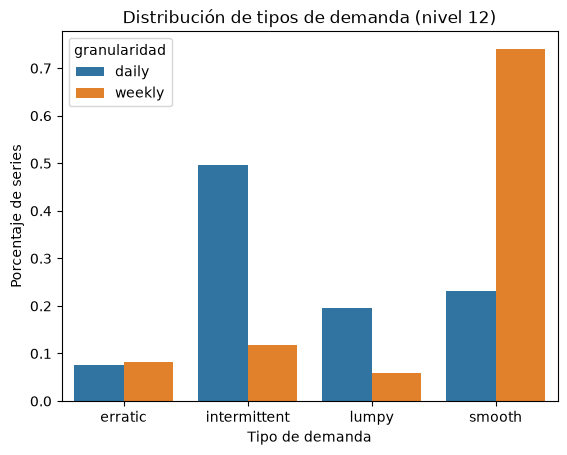

In [57]:
sns.barplot(
    data=resumen_total.query('level == 12'),
    x='tipo_demanda',
    y='series_pct',
    hue='granularidad'
)
plt.title('Distribución de tipos de demanda (nivel 12)')
plt.ylabel('Porcentaje de series')
plt.xlabel('Tipo de demanda')
plt.show()